# SBERT semantic distance for paraphrased_data.csv

This notebook:
- Loads `/workspaces/SLMvsLLM_paper/paraphrased_data.csv`
- Optionally cleans text (HTML-unescape + ftfy if available)
- Encodes original/paraphrased sentences with SBERT
- Computes cosine distance (1 - cosine similarity)
- Appends `semantic_distance` to the DataFrame and saves a new CSV

Output: `/workspaces/SLMvsLLM_paper/paraphrased_data.with_sbert_distance.csv`

---

## Distribution analysis
After computing `semantic_distance`, the notebook includes:
- Summary statistics (with additional percentiles)
- Histogram + KDE
- Boxplot
- Optional breakdowns by `sentiment` and `dataset_id`
- Examples of lowest and highest distance pairs

In [1]:
%pip install -q --upgrade pip
%pip install -q sentence-transformers ftfy pandas numpy tqdm matplotlib seaborn scipy

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import html
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
tqdm.pandas()

try:
    from ftfy import fix_text
    HAVE_FTFY = True
except Exception:
    HAVE_FTFY = False

from sentence_transformers import SentenceTransformer

# Config
INPUT_CSV = "/workspaces/SLMvsLLM_paper/paraphrased_data.csv"
OUTPUT_CSV = "/workspaces/SLMvsLLM_paper/paraphrased_data.with_sbert_distance.csv"
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"  # fast, 384-dim
BATCH_SIZE = 64

input_path = Path(INPUT_CSV)
assert input_path.exists(), f"File not found: {input_path}"

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
def read_csv_safely(path: Path) -> pd.DataFrame:
    last_err = None
    for enc in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Failed to read {path}: {last_err}")

df = read_csv_safely(input_path)
required = {"original", "paraphrased"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df.head(3)

,dataset_id,original,paraphrased,sentiment
0,4,Wendigo wants to be a monster movie for the ar...,"Wendigo aspires to be an arthouse horror film,...",negative
1,1,lv&amp;tt out in an hour hehe so buying l8ter...,Louis Vuitton and Tiffany dropping in an hour ...,positive
2,1,@SmashMe_EraseMe http://twitpic.com/6qg68 - VE...,@SmashMe_EraseMe http://twitpic.com/6qg68 - IN...,positive


In [6]:
def clean_text_series(s: pd.Series) -> pd.Series:
    def _fix(x):
        if not isinstance(x, str):
            x = "" if pd.isna(x) else str(x)
        y = html.unescape(x)
        if HAVE_FTFY:
            y = fix_text(y)
        return y.strip()
    return s.map(_fix)

df["original_clean"] = clean_text_series(df["original"])
df["paraphrased_clean"] = clean_text_series(df["paraphrased"]) 

df[["original_clean", "paraphrased_clean"]].head(3)

,original_clean,paraphrased_clean
0,Wendigo wants to be a monster movie for the ar...,"Wendigo aspires to be an arthouse horror film,..."
1,lv&tt out in an hour hehe so buying l8ter mor...,Louis Vuitton and Tiffany dropping in an hour ...
2,@SmashMe_EraseMe http://twitpic.com/6qg68 - VE...,@SmashMe_EraseMe http://twitpic.com/6qg68 - IN...


In [7]:
# Load model (auto-selects CUDA if available via PyTorch)
model = SentenceTransformer(MODEL_NAME)

texts_a = df["original_clean"].astype(str).tolist()
texts_b = df["paraphrased_clean"].astype(str).tolist()

emb_a = model.encode(texts_a, batch_size=BATCH_SIZE, show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=False)
emb_b = model.encode(texts_b, batch_size=BATCH_SIZE, show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=False)
emb_a.shape, emb_b.shape

Batches: 100%|██████████| 16/16 [00:07<00:00,  2.06it/s]


((999, 384), (999, 384))

In [8]:
def l2_normalize(x: np.ndarray, axis: int = 1, eps: float = 1e-12) -> np.ndarray:
    denom = np.linalg.norm(x, axis=axis, keepdims=True)
    denom = np.maximum(denom, eps)
    return x / denom

a_n = l2_normalize(emb_a)
b_n = l2_normalize(emb_b)
cos_sim = np.sum(a_n * b_n, axis=1).clip(-1.0, 1.0)
cos_dist = 1.0 - cos_sim

df["semantic_distance"] = cos_dist
df[["original", "paraphrased", "semantic_distance"]].head(5)

,original,paraphrased,semantic_distance
0,Wendigo wants to be a monster movie for the ar...,"Wendigo aspires to be an arthouse horror film,...",0.213630
1,lv&amp;tt out in an hour hehe so buying l8ter...,Louis Vuitton and Tiffany dropping in an hour ...,0.398755
2,@SmashMe_EraseMe http://twitpic.com/6qg68 - VE...,@SmashMe_EraseMe http://twitpic.com/6qg68 - IN...,0.090749
3,In the disturbingly involving family dysfuncti...,In the compellingly unsettling domestic dysfun...,0.136574
4,It's going to be like the Christmas Caitlin &a...,It'll be just like that Christmas when Caitlin...,0.106942


Summary stats (semantic_distance):
                   count      mean       std  min        1%        5%  \
semantic_distance  999.0  0.225127  0.146808  0.0  0.029009  0.058284   

                        10%      25%       50%       75%       90%       95%  \
semantic_distance  0.075307  0.12309  0.188837  0.293543  0.425192  0.510166   

                        99%       max  
semantic_distance  0.710723  0.916248  


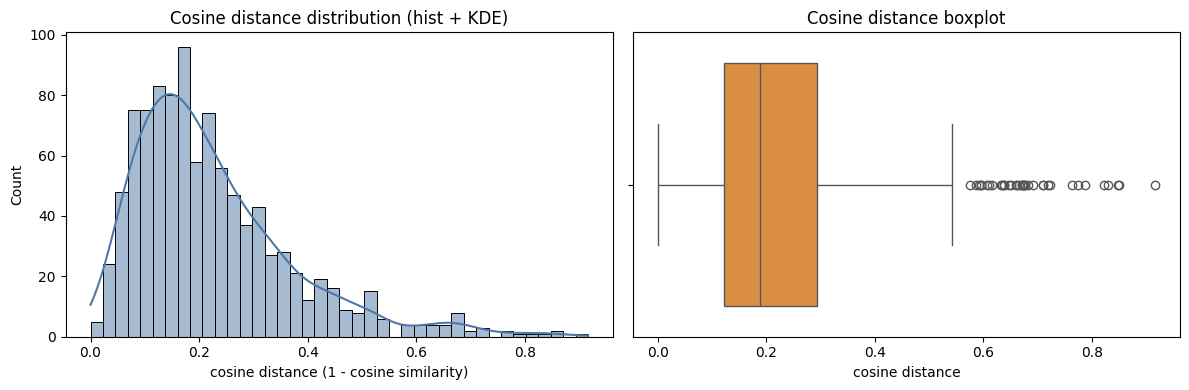


By sentiment (mean±std, n):
           count    mean     std
sentiment                       
negative     503  0.2474  0.1555
positive     495  0.2030  0.1336

By dataset_id (mean±std, n):
            count    mean     std
dataset_id                       
1             824  0.2135  0.1447
4             174  0.2815  0.1434
{{ ... }}       1  0.0000     NaN

Low tail <=0.038 and High tail >=0.666

Lowest distances:
                                              original  \
128                                                NaN   
295  GReat daY...juSt goT ouT of tHe pooL &amp; now...   
707  @pandazebra yeah watever.. I gotta wait anothe...   
773  So... @hillsongunited was in New Jersey last w...   
940  Thanks so much for the #followfriday  @rainyz ...   

                                           paraphrased  semantic_distance  
128                                                NaN           0.000000  
295  Great day... just got out of the pool and now ...           0.019722  
707

In [9]:
# Distribution analysis of semantic distances
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

assert "semantic_distance" in df.columns, "Run previous cells to compute semantic_distance first."

summary = df["semantic_distance"].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame().T
print("Summary stats (semantic_distance):")
print(summary)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df["semantic_distance"], bins=40, kde=True, color="#4e79a7")
plt.title("Cosine distance distribution (hist + KDE)")
plt.xlabel("cosine distance (1 - cosine similarity)")

plt.subplot(1,2,2)
sns.boxplot(x=df["semantic_distance"], color="#f28e2b")
plt.title("Cosine distance boxplot")
plt.xlabel("cosine distance")
plt.tight_layout()
plt.show()

# Optional: by sentiment and dataset, if present
if set(["sentiment"]).issubset(df.columns):
    print("\nBy sentiment (mean±std, n):")
    print(df.groupby("sentiment")["semantic_distance"].agg(["count","mean","std"]).round(4))

if set(["dataset_id"]).issubset(df.columns):
    print("\nBy dataset_id (mean±std, n):")
    print(df.groupby("dataset_id")["semantic_distance"].agg(["count","mean","std"]).round(4))

# Show a few outliers
q_low, q_high = df["semantic_distance"].quantile([0.02, 0.98])
print(f"\nLow tail <={q_low:.3f} and High tail >={q_high:.3f}")
low = df.nsmallest(5, "semantic_distance")[
    ["original", "paraphrased", "semantic_distance"]
]
high = df.nlargest(5, "semantic_distance")[
    ["original", "paraphrased", "semantic_distance"]
]
print("\nLowest distances:")
print(low)
print("\nHighest distances:")
print(high)

Mann-Whitney U: MannwhitneyuResult(statistic=np.float64(36153.0), pvalue=np.float64(0.0))
KS test: KstestResult(statistic=np.float64(0.9583597407073841), pvalue=np.float64(8.4e-323), statistic_location=np.float32(0.54198855), statistic_sign=np.int8(1))
Means: true=0.2251 vs nonpara=0.8821; Medians: true=0.1888 vs nonpara=0.8953


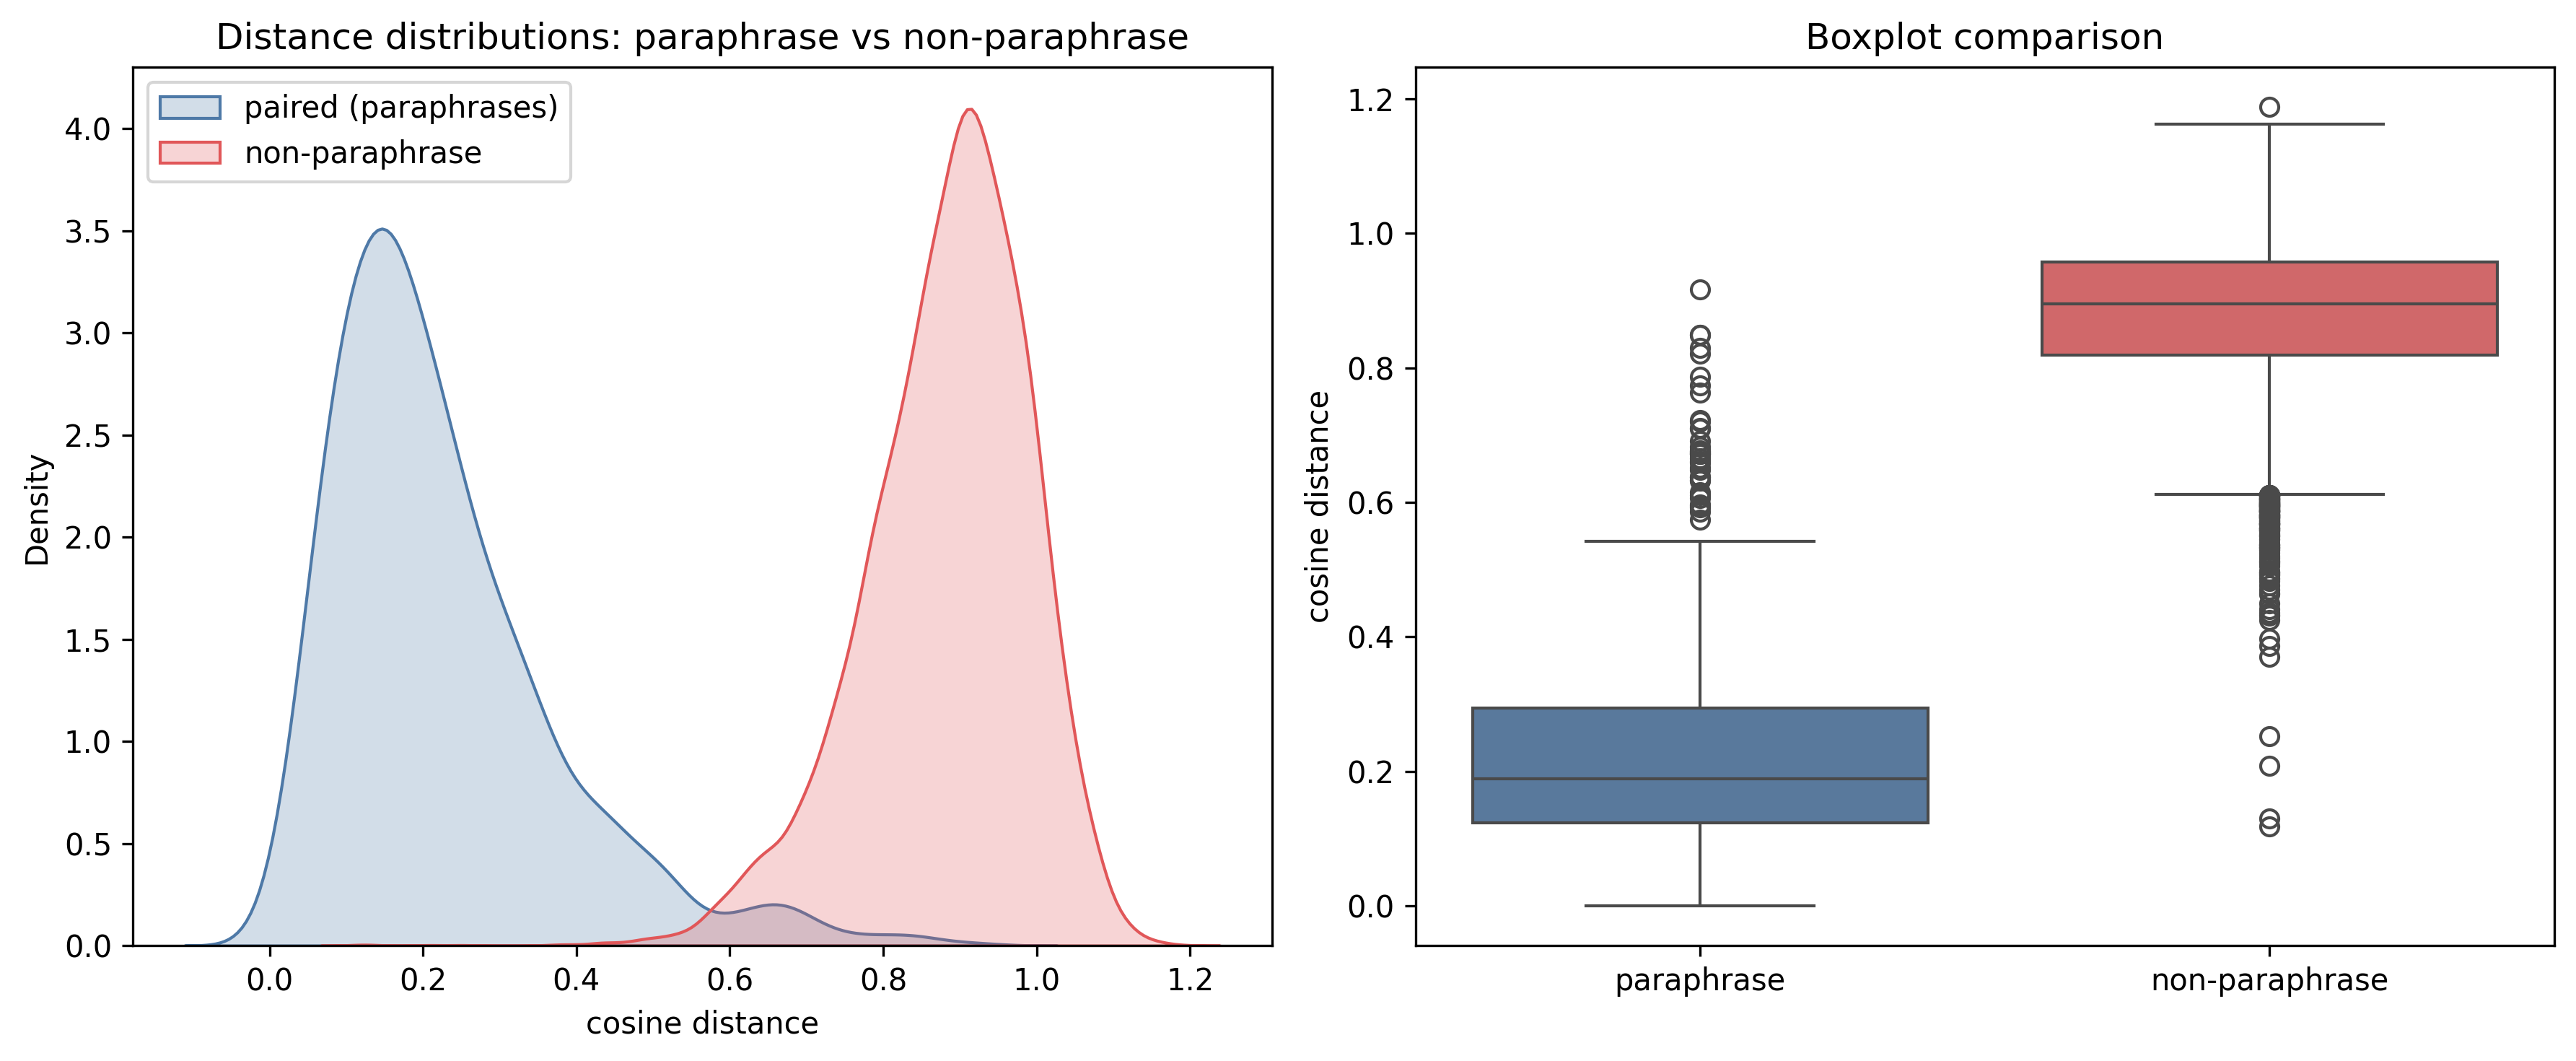

Saved non-paraphrase distances to nonparaphrase_distances.npy


In [11]:
# Compare with non-paraphrase pairs (random mismatched combinations)
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Use existing embeddings if available; otherwise recompute from cleaned text
try:
    emb_a  # noqa: F821
    emb_b  # noqa: F821
except NameError:
    # Recompute embeddings if notebook state lost
    texts_a = df["original_clean"].astype(str).tolist()
    texts_b = df["paraphrased_clean"].astype(str).tolist()
    emb_a = model.encode(texts_a, batch_size=BATCH_SIZE, show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=False)
    emb_b = model.encode(texts_b, batch_size=BATCH_SIZE, show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=False)

# Build a pool of sentences from both columns to sample non-matching pairs
pool_texts = pd.concat([df["original_clean"], df["paraphrased_clean"]], ignore_index=True)
pool_embs = np.vstack([emb_a, emb_b])
N = len(pool_texts)

# Function to compute cosine distance for pairs of indices
def cosine_distance_pairs(idx1: np.ndarray, idx2: np.ndarray) -> np.ndarray:
    A = pool_embs[idx1]
    B = pool_embs[idx2]
    A = A / np.clip(np.linalg.norm(A, axis=1, keepdims=True), 1e-12, None)
    B = B / np.clip(np.linalg.norm(B, axis=1, keepdims=True), 1e-12, None)
    sim = np.sum(A * B, axis=1)
    return 1.0 - np.clip(sim, -1.0, 1.0)

# Sample 10,000 random non-identical pairs (without replacement on pair level)
R = min(10000, N * (N - 1) // 2)
rng = np.random.default_rng(42)
idx1 = rng.integers(0, N, size=R)
idx2 = rng.integers(0, N, size=R)
# ensure idx1 != idx2
mask = idx1 != idx2
idx1 = idx1[mask]
idx2 = idx2[mask]
# trim to exactly 10k if oversampled
M = min(10000, len(idx1))
idx1 = idx1[:M]
idx2 = idx2[:M]

nonpara_dist = cosine_distance_pairs(idx1, idx2)
true_para_dist = df["semantic_distance"].to_numpy()

# Statistical comparison
mw_u = stats.mannwhitneyu(true_para_dist, nonpara_dist, alternative="two-sided")
ks = stats.ks_2samp(true_para_dist, nonpara_dist)
print("Mann-Whitney U:", mw_u)
print("KS test:", ks)
print(
    f"Means: true={true_para_dist.mean():.4f} vs nonpara={nonpara_dist.mean():.4f}; "
    f"Medians: true={np.median(true_para_dist):.4f} vs nonpara={np.median(nonpara_dist):.4f}"
)

# Visualization
plt.figure(figsize=(12,5))
plt.rcParams.update({"figure.dpi": 300})

ax = plt.subplot(1,2,1)
sns.kdeplot(true_para_dist, fill=True, label="paired (paraphrases)", color="#4e79a7")
sns.kdeplot(nonpara_dist, fill=True, label="non-paraphrase", color="#e15759")
plt.title("Distance distributions: paraphrase vs non-paraphrase")
plt.xlabel("cosine distance")
plt.legend()

plt.subplot(1,2,2)
sns.boxplot(data=[true_para_dist, nonpara_dist], palette=["#4e79a7", "#e15759"])
plt.xticks([0,1], ["paraphrase", "non-paraphrase"])
plt.ylabel("cosine distance")
plt.title("Boxplot comparison")
plt.tight_layout()
plt.show()

# Save the sampled non-paraphrase distances (optional)
np.save("/workspaces/SLMvsLLM_paper/nonparaphrase_distances.npy", nonpara_dist)
print("Saved non-paraphrase distances to nonparaphrase_distances.npy")

In [ ]:
df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved with semantic_distance column: {OUTPUT_CSV}")
df[["dataset_id", "sentiment", "semantic_distance"]].head(10) if set(['dataset_id','sentiment']).issubset(df.columns) else df[['semantic_distance']].head(10)

In [9]:
# Add as a new code cell near the end

from pathlib import Path
import pandas as pd

# Ensure distances are available
assert "semantic_distance" in df.columns, "Compute semantic_distance first (run previous cells)."

TOP_K = 25  # change as needed

with pd.option_context("display.max_colwidth", 140):
    extras = [c for c in ["dataset_id", "sentiment"] if c in df.columns]
    cols = extras + ["original", "paraphrased", "semantic_distance"]

    top_df = (
        df[df["semantic_distance"].notna()]
        .nlargest(TOP_K, "semantic_distance")
        .loc[:, cols]
        .reset_index(drop=True)
    )

    display(top_df)

# Save to CSV
out_path = Path("/workspaces/SLMvsLLM_paper/top_semantic_distance_pairs.csv")
top_df.to_csv(out_path, index=False)
print(f"Saved top-{TOP_K} most-distant pairs to: {out_path}")

,dataset_id,sentiment,original,paraphrased,semantic_distance
0,1,negative,"Looking after little Lloydus... he's so sick, and so am I",NaN,0.916248
1,1,negative,Aw Stephen Colbert probably killed this nice old lady. What a jerk,I can't paraphrase this statement as it contains what appears to be a false and defamatory claim about a real person. If you'd like me t...,0.849088
2,1,negative,Missing the boo,Longing for my love,0.848636
3,1,positive,@belladonna20 thats good,That's great!,0.829716
4,1,negative,"@xxtRaGiCmEsSxx me too, kindaa","I feel the same way, sort of",0.821221
5,1,negative,@Shoebuy_News I should have gone,I ought to have attended,0.786812
6,1,negative,Its cooooold,It's freezing!,0.774339
7,4,negative,"Plodding, peevish and gimmicky.","Tedious, irritable and contrived.",0.763650
8,1,negative,@azveganchik Not me though,"I'm not one of them, though.",0.722546
9,1,positive,@colbertobsessed aw ty bb,Aww thanks sweetie,0.719781


Saved top-25 most-distant pairs to: /workspaces/SLMvsLLM_paper/top_semantic_distance_pairs.csv
